In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [10]:
df = pd.read_csv("diabetes.csv")

In [11]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [18]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [19]:
df.shape

(768, 9)

In [26]:
df['Age'] = df['Age'].replace(np.nan, df['Age'].mean())

In [27]:
#encoding categorical data : Not required because all columns are numerical.
# For viva you can say : The dataset contains only numerical features, so encoding was not needed.

In [28]:
X = df.drop("Outcome", axis=1)  
y = df["Outcome"]               

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

#Straight line separation

In [ ]:
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train, y_train)

svm_poly_pred = svm_poly.predict(X_test)

#Polynomial curved boundary

In [ ]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

svm_rbf_pred = svm_rbf.predict(X_test)

#Flexible curved boundary
#RBF = Radial Basis Function - It creates very flexible and complex curved boundaries.

In [36]:
correct = 0

for i in range(len(y_test)):
    if svm_pred[i] == list(y_test)[i]:
        correct += 1

svm_acc = correct / len(y_test)
svm_acc


0.7532467532467533

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)


In [39]:
correct = 0

for i in range(len(y_test)):
    if dt_pred[i] == list(y_test)[i]:
        correct += 1

dt_acc = correct / len(y_test)
dt_acc

0.7402597402597403

In [40]:
result = pd.DataFrame({
    "Model": ["SVM", "Decision Tree"],
    "Accuracy": [svm_acc, dt_acc]
})

result

,Model,Accuracy
0,SVM,0.753247
1,Decision Tree,0.740260


In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#ROC = Receiver Operating Characteristic


In [46]:
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

svm_probs = svm.predict_proba(X_test)[:, 1]


In [47]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_probs = dt.predict_proba(X_test)[:, 1]


In [48]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)


In [ ]:
auc_svm = auc(fpr_svm, tpr_svm)
auc_dt = auc(fpr_dt, tpr_dt)

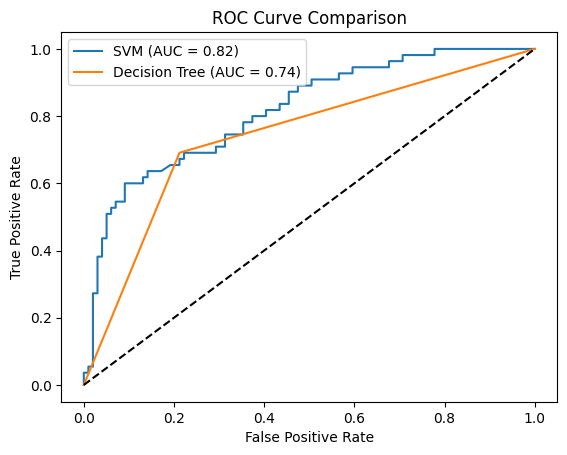

In [ ]:
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = %0.2f)" % auc_svm)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC = %0.2f)" % auc_dt)

plt.plot([0,1], [0,1], 'k--') 

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()